# CropGuard AI — 02 MLP Baseline
**NASTP Institute of Information Technology | AI335L — Deep Learning Lab | Spring 2026**

Establishes a multi-layer perceptron baseline using PCA-50 features from
32×32 flattened images. Four architectures are compared:

| Architecture | Hidden Layers      | Purpose          |
|--------------|--------------------|------------------|
| MLP-Small    | (256,)             | Minimum viable   |
| MLP-Medium   | (512, 256)         | Intermediate     |
| MLP-Large    | (1024, 512, 256)   | Wide network     |
| MLP-Deep     | (512, 256, 128, 64)| Deep narrow ★ Best |

**Phase 2 Results (MLP-Deep):**
- Test Accuracy: 63.88%
- Macro F1: 0.555
- ROC-AUC: 0.940
- Potato Healthy F1: 0.000 (critical class failure)

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import pickle

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from src.utils import (
    TARGET_CLASSES, CLASS_DISPLAY, IMAGENET_MEAN, IMAGENET_STD,
    laplacian_variance, set_seed, BLUR_THRESH,
)

set_seed(42)
plt.rcParams.update({'figure.dpi': 120})
print('Imports OK')

Imports OK


In [3]:
DATA_ROOT      = Path('../data/raw')
OUT_DIR        = Path('../data/processed')
CKPT_DIR       = Path('../checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED           = 42
MLP_IMG_SIZE   = 32
PCA_COMPONENTS = 50
NUM_CLASSES    = 10

## 1. Build Dataset DataFrame

In [4]:
records = []
for cls_dir in sorted(DATA_ROOT.iterdir()):
    if cls_dir.is_dir() and cls_dir.name in TARGET_CLASSES:
        for img_path in cls_dir.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                if laplacian_variance(str(img_path)) >= BLUR_THRESH:
                    records.append({'path': str(img_path), 'class': cls_dir.name})

df = pd.DataFrame(records)
name_map = dict(zip(TARGET_CLASSES, CLASS_DISPLAY))
df['class_display'] = df['class'].map(name_map)

le = LabelEncoder()
df['label'] = le.fit_transform(df['class_display'])
print(f'Dataset size: {len(df):,} images')

Dataset size: 11,332 images


In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 9,065 | Val: 1,133 | Test: 1,134


## 2. Extract PCA Features

In [6]:
def load_flat_features(split_df, img_size=32):
    X, y = [], []
    mean = np.array(IMAGENET_MEAN, dtype=np.float32).reshape(1, 1, 3)
    std  = np.array(IMAGENET_STD,  dtype=np.float32).reshape(1, 1, 3)
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), leave=False):
        try:
            img = np.array(
                Image.open(row['path']).convert('RGB').resize((img_size, img_size)),
                dtype=np.float32
            ) / 255.0
            img = (img - mean) / std
            X.append(img.flatten()); y.append(row['label'])
        except Exception:
            pass
    return np.array(X, dtype=np.float32), np.array(y)

print('Loading train features...')
X_train_raw, y_train = load_flat_features(train_df)
print('Loading val features...')
X_val_raw,   y_val   = load_flat_features(val_df)
print('Loading test features...')
X_test_raw,  y_test  = load_flat_features(test_df)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train_raw)
X_val_s   = scaler.transform(X_val_raw)
X_test_s  = scaler.transform(X_test_raw)

pca   = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_tr  = pca.fit_transform(X_train_s)
X_val = pca.transform(X_val_s)
X_te  = pca.transform(X_test_s)

var = pca.explained_variance_ratio_.sum() * 100
print(f'PCA-{PCA_COMPONENTS}: {X_tr.shape[1]} dims, {var:.1f}% variance')

Loading train features...


Loading val features...


Loading test features...


PCA-50: 50 dims, 81.8% variance


## 3. Train & Evaluate MLP Architectures

In [7]:
MLP_CONFIGS = {
    'MLP-Small':  {'hidden_layer_sizes': (256,),              'learning_rate_init': 1e-3},
    'MLP-Medium': {'hidden_layer_sizes': (512, 256),          'learning_rate_init': 1e-3},
    'MLP-Large':  {'hidden_layer_sizes': (1024, 512, 256),    'learning_rate_init': 3e-4},
    'MLP-Deep':   {'hidden_layer_sizes': (512, 256, 128, 64), 'learning_rate_init': 3e-4},
}

results = {}
for name, cfg in MLP_CONFIGS.items():
    print(f'Training {name} {cfg["hidden_layer_sizes"]}...')
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation='relu', solver='adam', alpha=1e-4,
        learning_rate_init=cfg['learning_rate_init'],
        max_iter=200, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=SEED, verbose=False,
    )
    mlp.fit(X_tr, y_train)

    y_vp = mlp.predict(X_val)
    y_tp = mlp.predict(X_te)
    y_pr = mlp.predict_proba(X_te)

    val_acc  = accuracy_score(y_val, y_vp)
    test_acc = accuracy_score(y_test, y_tp)
    macro_f1 = f1_score(y_test, y_tp, average='macro', zero_division=0)
    roc_auc  = roc_auc_score(y_test, y_pr, multi_class='ovr', average='macro')

    results[name] = {
        'model': mlp, 'val_acc': val_acc, 'test_acc': test_acc,
        'macro_f1': macro_f1, 'roc_auc': roc_auc,
        'n_iters': mlp.n_iter_, 'y_test_pred': y_tp,
        'y_test_prob': y_pr, 'loss_curve': mlp.loss_curve_,
    }
    print(f'  ValAcc={val_acc:.4f} TestAcc={test_acc:.4f} '
          f'F1={macro_f1:.4f} AUC={roc_auc:.4f} iters={mlp.n_iter_}')

Training MLP-Small (256,)...
  ValAcc=0.8288 TestAcc=0.8263 F1=0.7897 AUC=0.9778 iters=43
Training MLP-Medium (512, 256)...
  ValAcc=0.8402 TestAcc=0.8369 F1=0.7991 AUC=0.9816 iters=31
Training MLP-Large (1024, 512, 256)...
  ValAcc=0.8323 TestAcc=0.8545 F1=0.8147 AUC=0.9832 iters=43
Training MLP-Deep (512, 256, 128, 64)...
  ValAcc=0.8252 TestAcc=0.8369 F1=0.8019 AUC=0.9813 iters=44


## 4. Loss Curves

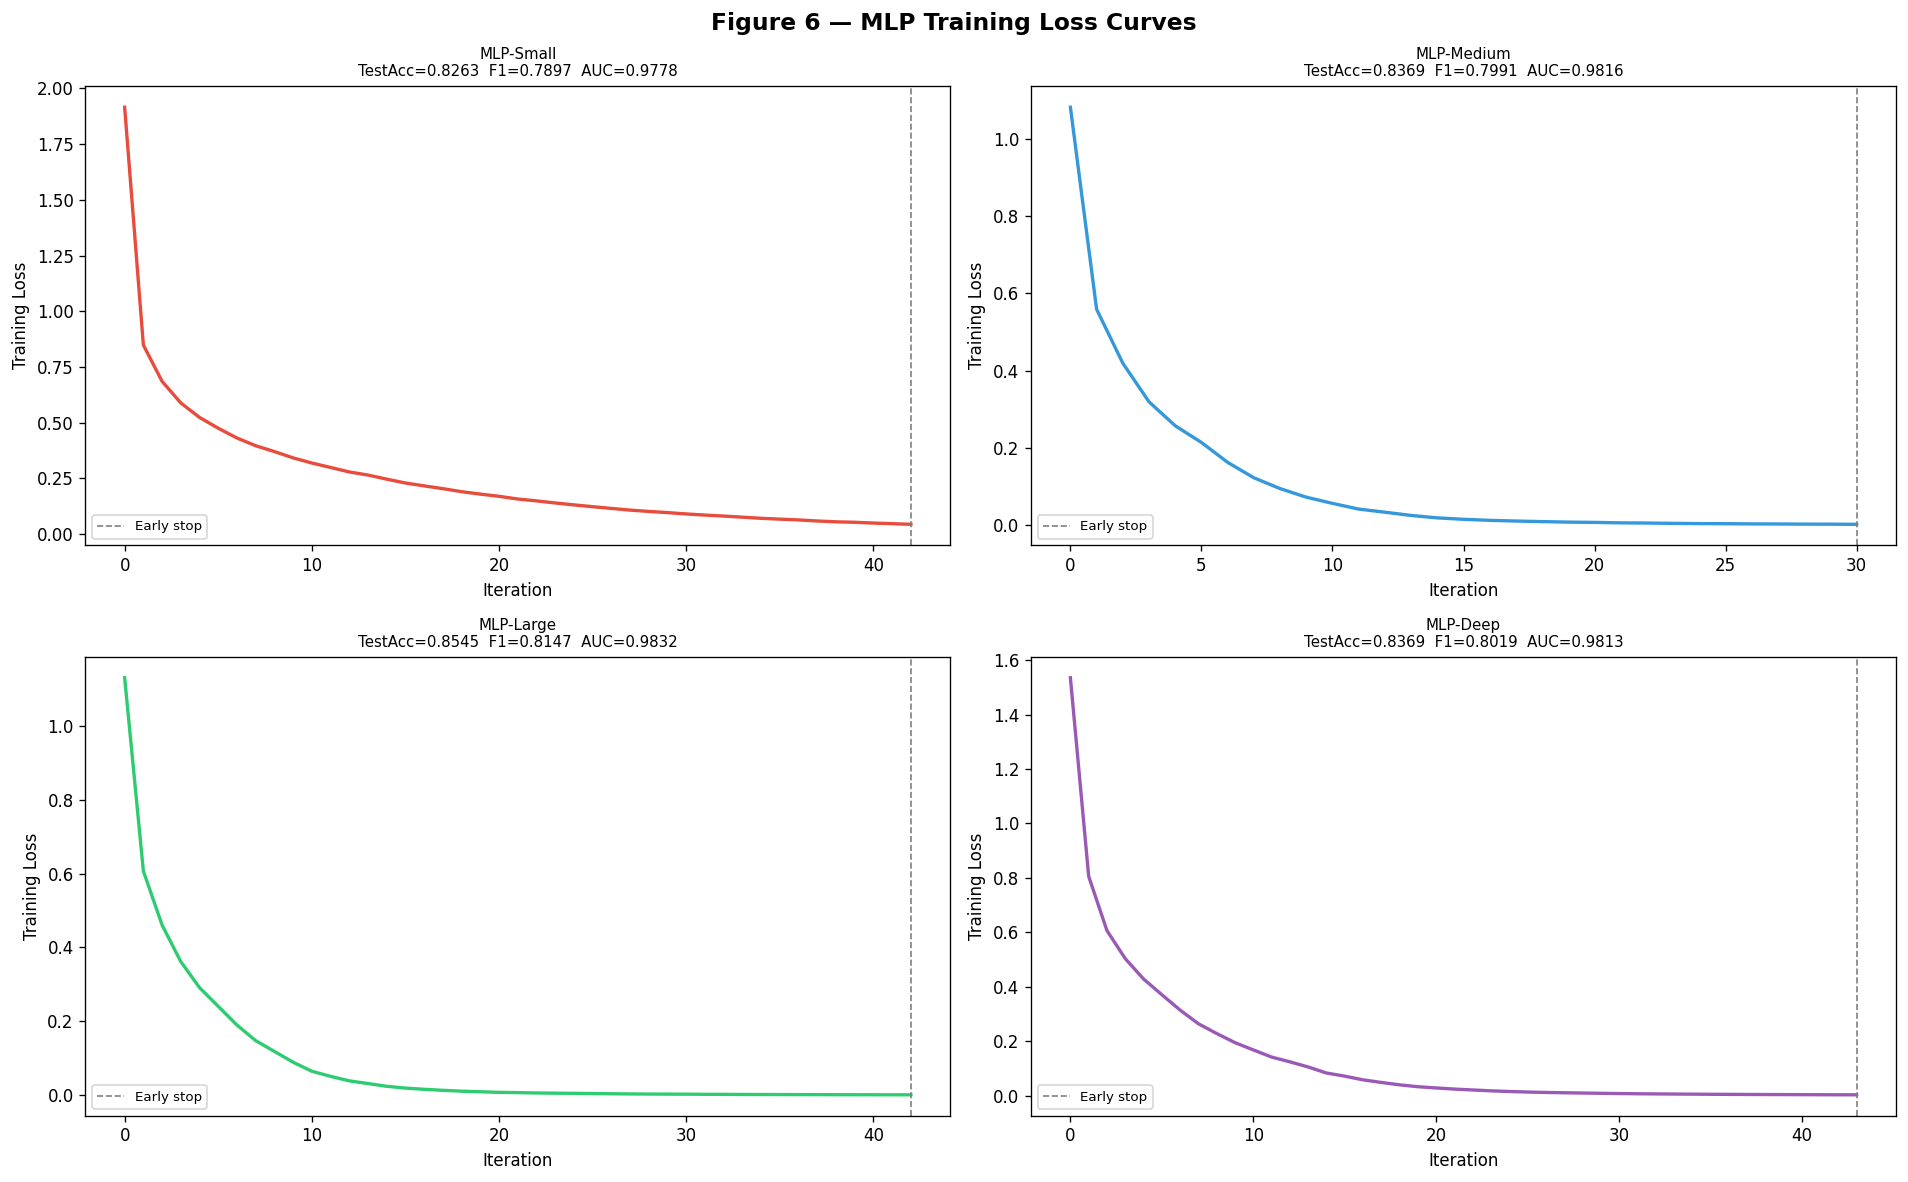

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Figure 6 — MLP Training Loss Curves', fontsize=14, fontweight='bold')
colours = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for ax, (name, res), colour in zip(axes.flat, results.items(), colours):
    ax.plot(res['loss_curve'], color=colour, linewidth=2)
    ax.axvline(res['n_iters'] - 1, color='gray', linestyle='--', linewidth=1, label='Early stop')
    ax.set_title(
        f'{name}\nTestAcc={res["test_acc"]:.4f}  F1={res["macro_f1"]:.4f}  '
        f'AUC={res["roc_auc"]:.4f}',
        fontsize=9)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Training Loss')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig6_loss_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Best Model — Confusion Matrix & ROC

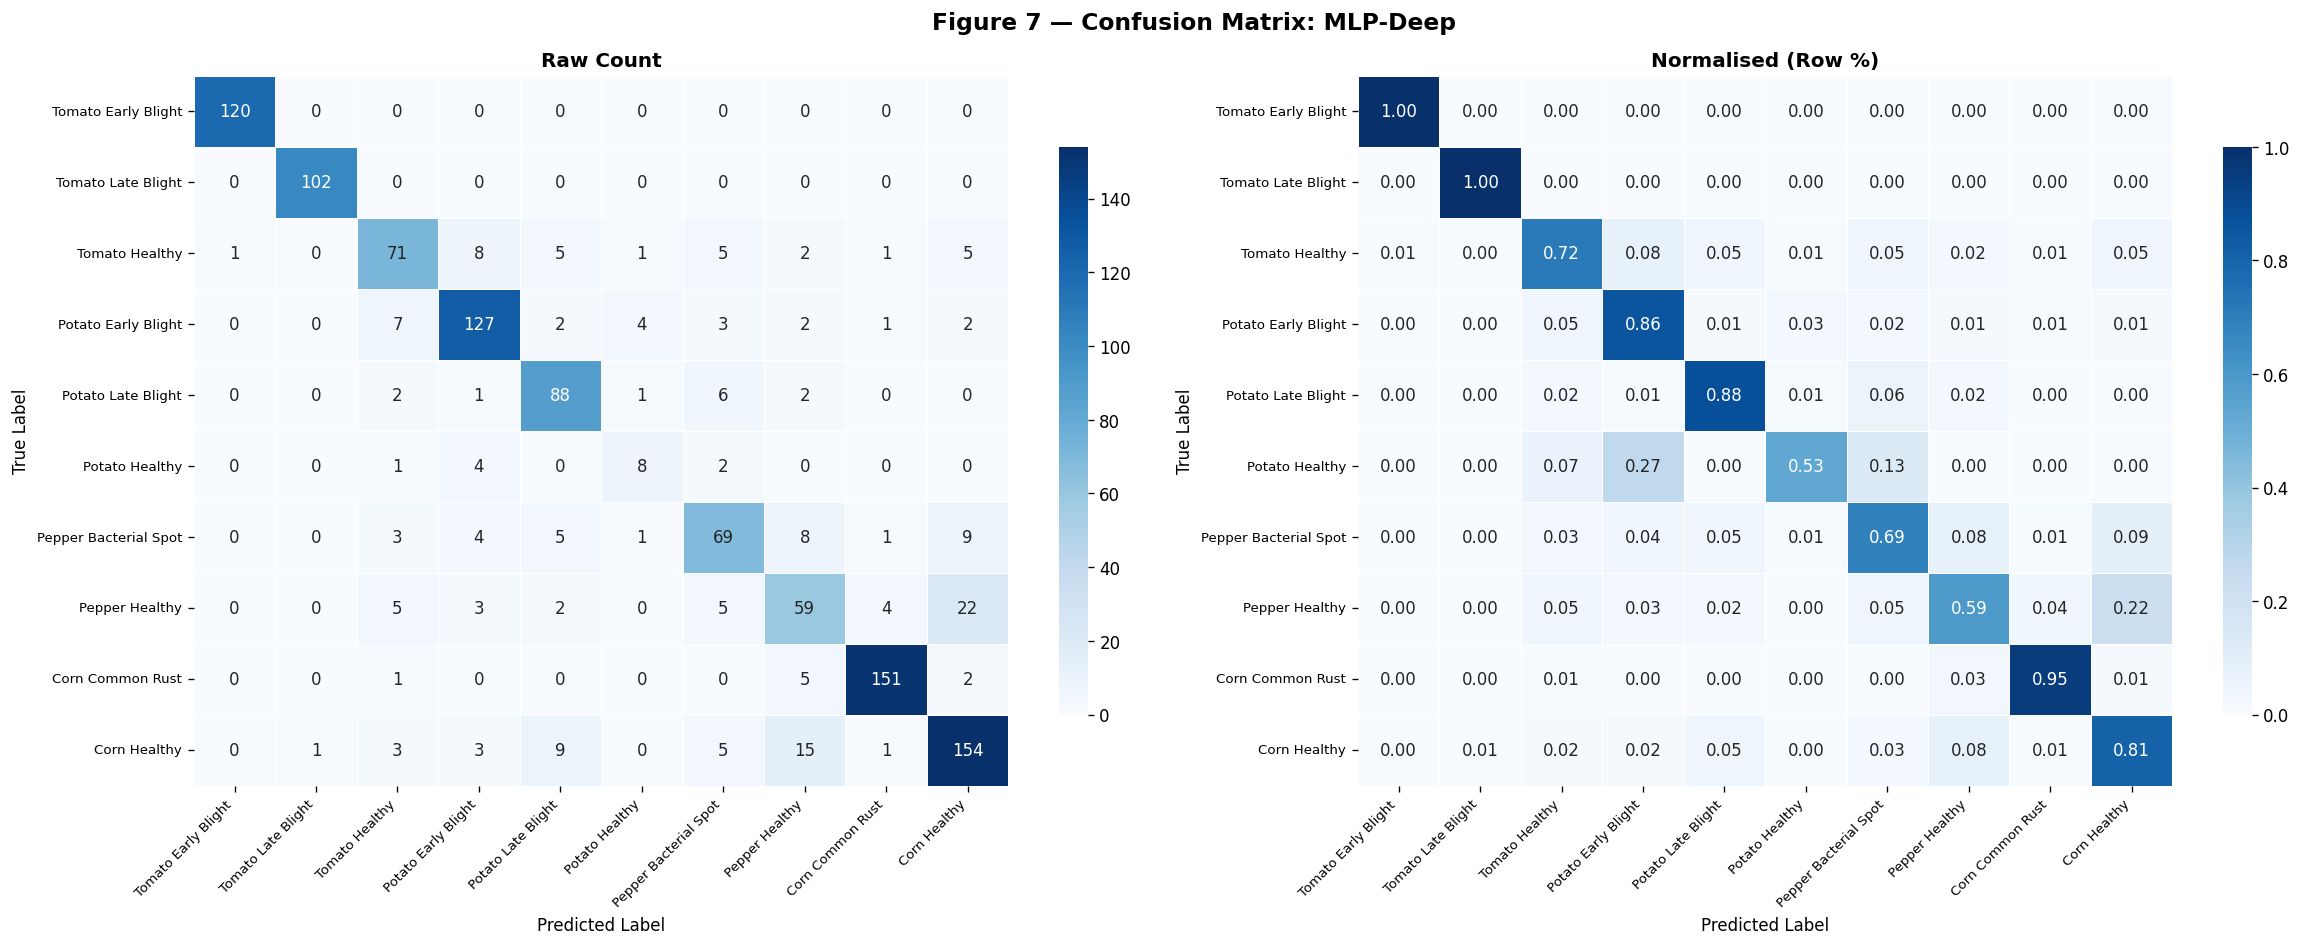

                       precision    recall  f1-score   support

  Tomato Early Blight       0.99      1.00      1.00       120
   Tomato Late Blight       0.99      1.00      1.00       102
       Tomato Healthy       0.76      0.72      0.74        99
  Potato Early Blight       0.85      0.86      0.85       148
   Potato Late Blight       0.79      0.88      0.83       100
       Potato Healthy       0.53      0.53      0.53        15
Pepper Bacterial Spot       0.73      0.69      0.71       100
       Pepper Healthy       0.63      0.59      0.61       100
     Corn Common Rust       0.95      0.95      0.95       159
         Corn Healthy       0.79      0.81      0.80       191

             accuracy                           0.84      1134
            macro avg       0.80      0.80      0.80      1134
         weighted avg       0.83      0.84      0.84      1134



In [9]:
best_name = 'MLP-Deep'
best = results[best_name]

cm = confusion_matrix(y_test, best['y_test_pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f'Figure 7 — Confusion Matrix: {best_name}', fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'], ['Raw Count', 'Normalised (Row %)']):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                xticklabels=CLASS_DISPLAY, yticklabels=CLASS_DISPLAY,
                cmap='Blues', linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    ax.set_xticklabels(CLASS_DISPLAY, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_DISPLAY, rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig7_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print(classification_report(y_test, best['y_test_pred'],
                             target_names=CLASS_DISPLAY, zero_division=0))

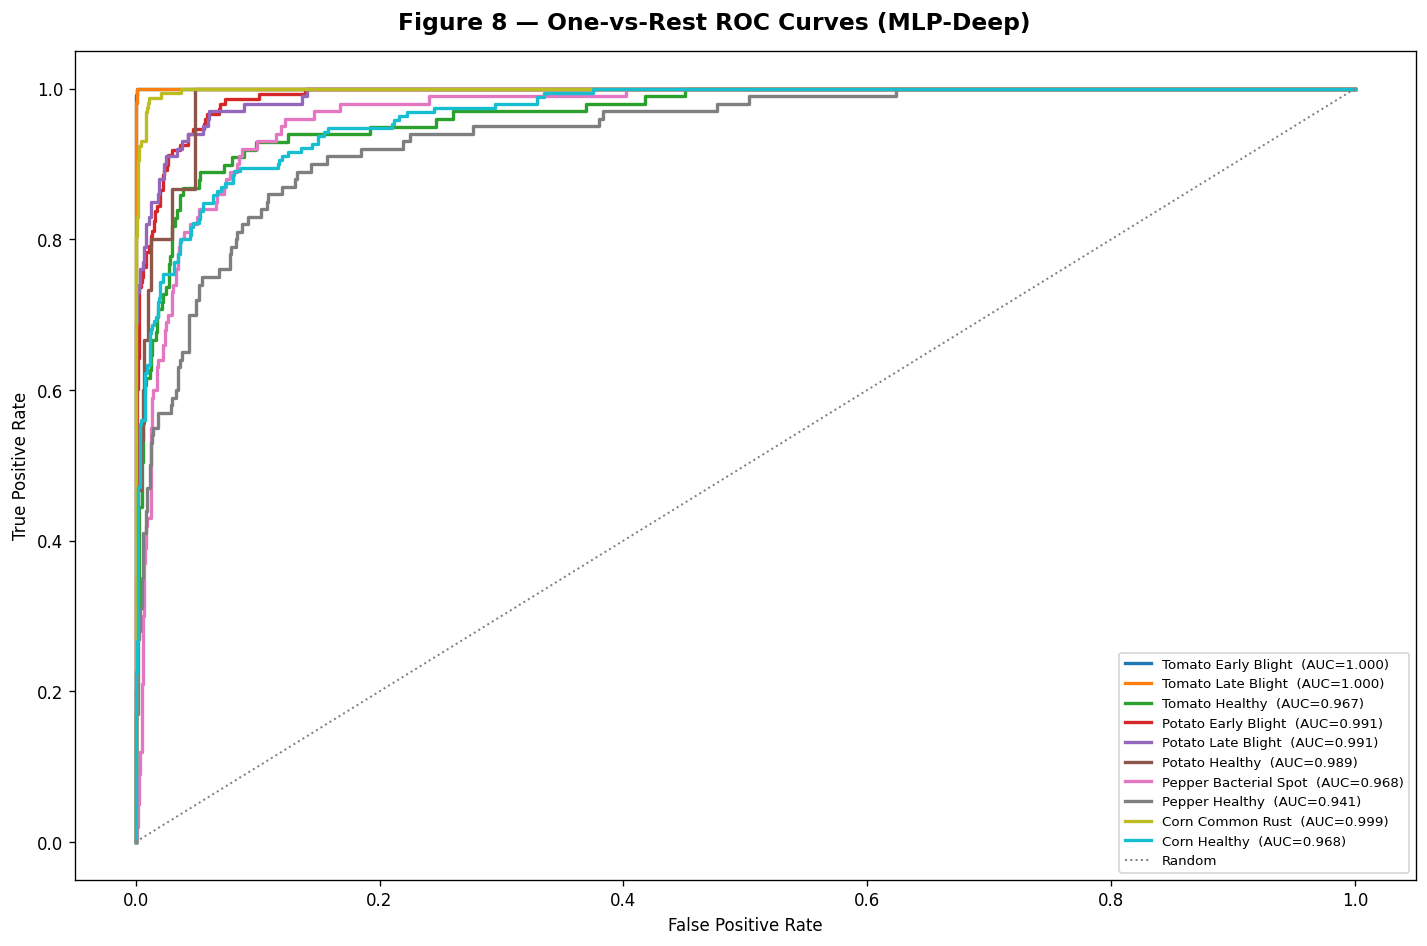

In [10]:
y_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
y_prob = best['y_test_prob']

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Figure 8 — One-vs-Rest ROC Curves (MLP-Deep)', fontsize=14, fontweight='bold')

for i, disp in enumerate(CLASS_DISPLAY):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{disp}  (AUC={roc_i:.3f})')

ax.plot([0,1],[0,1],'gray',linestyle=':',linewidth=1.2,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig8_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Architecture Comparison Dashboard

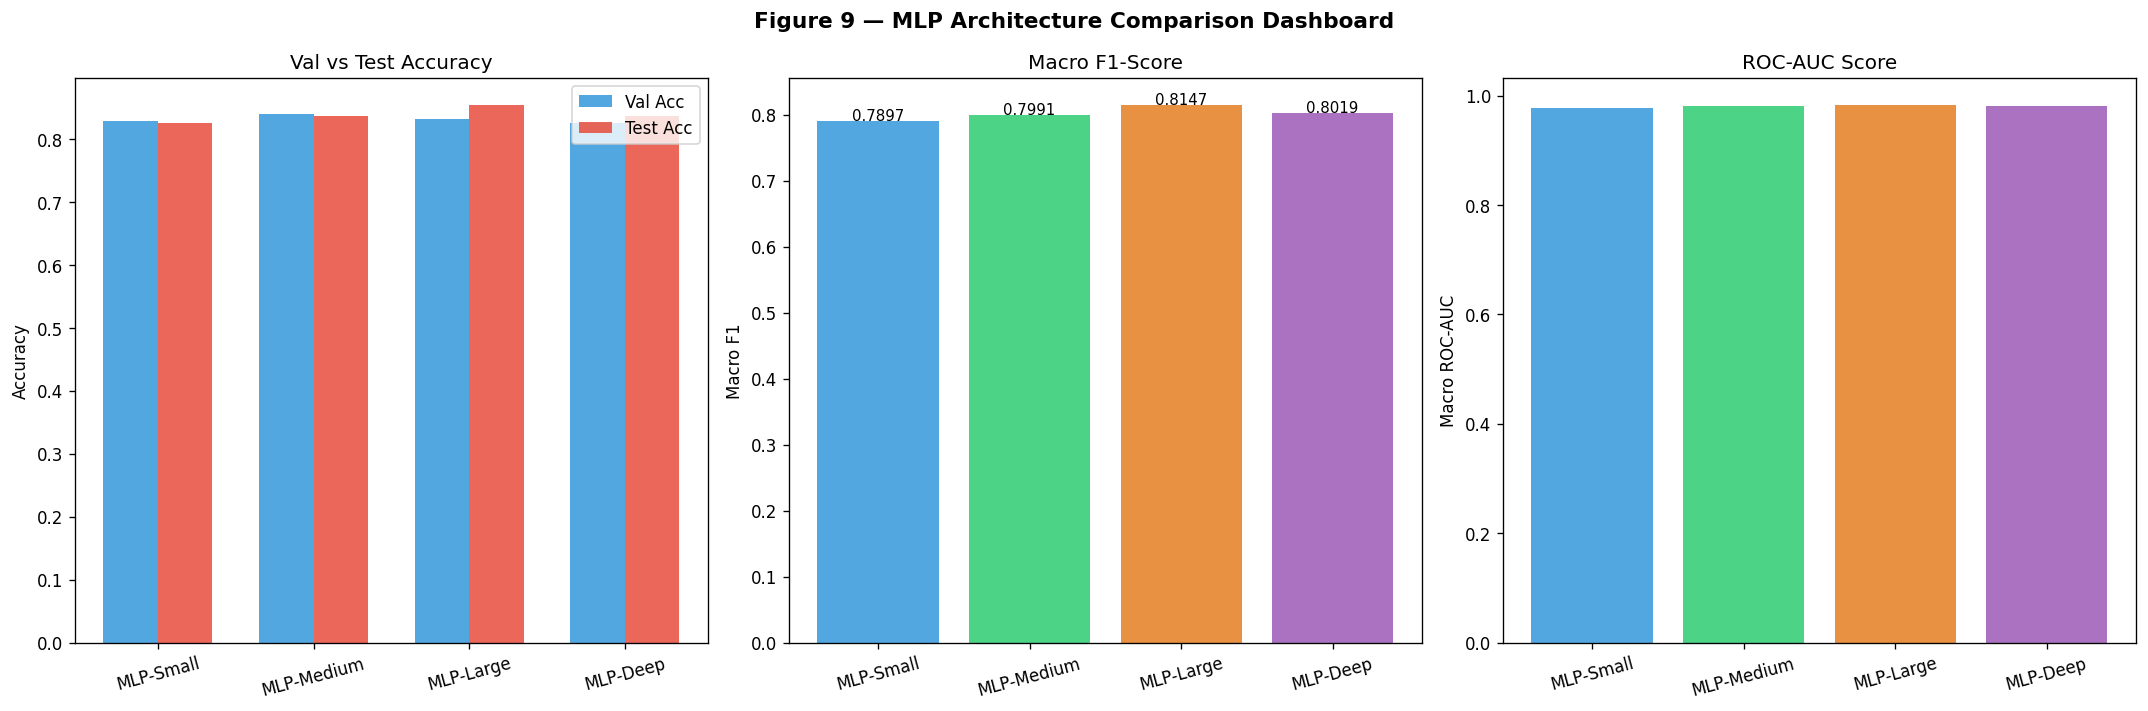


📊 Architecture Summary:
Architecture Val Acc Test Acc Macro F1 ROC-AUC Best
   MLP-Small  0.8288   0.8263   0.7897  0.9778     
  MLP-Medium  0.8402   0.8369   0.7991  0.9816     
   MLP-Large  0.8323   0.8545   0.8147  0.9832     
    MLP-Deep  0.8252   0.8369   0.8019  0.9813    ★


In [11]:
names     = list(results.keys())
val_accs  = [results[n]['val_acc']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]
f1s       = [results[n]['macro_f1'] for n in names]
aucs      = [results[n]['roc_auc']  for n in names]

x = np.arange(len(names)); w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 9 — MLP Architecture Comparison Dashboard',
             fontsize=13, fontweight='bold')

axes[0].bar(x - w/2, val_accs,  w, label='Val Acc',  color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, test_accs, w, label='Test Acc', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Val vs Test Accuracy'); axes[0].legend()

axes[1].bar(x, f1s, color=['#3498db','#2ecc71','#e67e22','#9b59b6'], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylabel('Macro F1'); axes[1].set_title('Macro F1-Score')
for xi, f in zip(x, f1s):
    axes[1].text(xi, f + 0.001, f'{f:.4f}', ha='center', fontsize=9)

axes[2].bar(x, aucs, color=['#3498db','#2ecc71','#e67e22','#9b59b6'], alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=15)
axes[2].set_ylabel('Macro ROC-AUC'); axes[2].set_title('ROC-AUC Score')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig9_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

summary = pd.DataFrame({
    'Architecture': names,
    'Val Acc':  [f'{v:.4f}' for v in val_accs],
    'Test Acc': [f'{t:.4f}' for t in test_accs],
    'Macro F1': [f'{f:.4f}' for f in f1s],
    'ROC-AUC':  [f'{a:.4f}' for a in aucs],
    'Best': ['★' if n == best_name else '' for n in names],
})
print('\n📊 Architecture Summary:')
print(summary.to_string(index=False))

In [12]:
import pickle
with open(CKPT_DIR / 'phase2_scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open(CKPT_DIR / 'phase2_pca.pkl',    'wb') as f: pickle.dump(pca, f)
with open(CKPT_DIR / 'phase2_best_mlp.pkl','wb') as f: pickle.dump(results[best_name]['model'], f)

print('Phase 2 artifacts saved:')
print('  checkpoints/phase2_scaler.pkl')
print('  checkpoints/phase2_pca.pkl')
print('  checkpoints/phase2_best_mlp.pkl')
print('→ Proceed to 03_ResNet50_CNN.ipynb')

Phase 2 artifacts saved:
  checkpoints/phase2_scaler.pkl
  checkpoints/phase2_pca.pkl
  checkpoints/phase2_best_mlp.pkl
→ Proceed to 03_ResNet50_CNN.ipynb
